In [1]:
from __future__ import annotations

import json
import math
import re
import unicodedata
from collections import Counter
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 200,
        "savefig.bbox": "tight",
        "font.size": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
    }
)

RNG = np.random.default_rng(20250914)

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "pyproject.toml").exists() or (cand / "runs").is_dir():
            return cand
    return p


ROOT = find_project_root()
RUNS_DIR = ROOT / "runs"
MANIFEST = ROOT / "data" / "manifests" / "m3di_test.parquet"
FIG_DIR = ROOT / "reports" / "figures" / "eval"
TAB_DIR = ROOT / "reports" / "tables" / "eval"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

# Campos del JSONL. Se resuelven por el primer alias presente.
FIELD_ALIASES = {
    "image_id": ["image_id", "id", "idx", "index"],
    "prediction": ["prediction", "pred", "output", "text", "caption_pred", "generated"],
    "reference": ["caption_ref", "caption", "reference", "caption_gt", "ref"],
}

# Modelos que recuperan de un pool en vez de generar: su BLEU no es comparable
# con el de los generativos sin proyección a conjunto cerrado (sección 9).
RETRIEVAL_MODELS = {"vljepa", "vl-jepa", "vl_jepa"}

# Columnas crudas que no son atributos evaluados pero alimentan la sección 4.5
# (el matiz continuo del que se deriva el nombre de color).
EXTRA_COLS = ["object_color"]

N_PERMUTATION_PAIRS = 2000  # pares para estimar S_0
DISC_QUANTILE = 0.75        # umbral tau de la discordancia
N_BOOTSTRAP = 10_000


@dataclass
class AttrSpec:
    """Especificación de un atributo y de cómo extraerlo del texto."""

    name: str                                   # columna con el valor verdadero
    label: str | None = None                    # nombre para tablas y figuras
    kind: str = "nominal"                       # nominal | ordinal
    order: list | None = None                   # orden de las clases (ordinal)
    surface: dict = field(default_factory=dict)  # valor GT -> formas superficiales
    anchors: tuple = ()                          # el valor debe aparecer cerca de esto
    exclude_anchors: tuple = ()                  # ...y lejos de esto
    window: int = 45                             # ventana de contexto en caracteres
    pattern: str | None = None                   # regex con grupo (?P<val>...) (override)

    def __post_init__(self):
        self.label = self.label or self.name


# Valores por defecto para Multimodal3DIdent. Ajustar tras leer el diagnóstico
# de la sección 5: esos son los captions reales, esto es solo una hipótesis.
POSITIONS_X = {0: ["left"], 1: ["center", "middle", "centre"], 2: ["right"]}
POSITIONS_Y = {0: ["top", "upper"], 1: ["mid", "middle", "center", "centre"], 2: ["bottom", "lower"]}

ATTRS: list[AttrSpec] = [
    AttrSpec(name="object_shape", label="forma"),
    AttrSpec(
        name="object_xpos",
        label="pos. x",
        kind="ordinal",
        order=[0, 1, 2],
        surface=POSITIONS_X,
        # "center" es compartido con el eje y: no se toma si le sigue izq/der.
        pattern=r"\b(?P<val>left|right|(?:centre|center|middle)(?![\s-]+(?:left|right)))\b",
    ),
    AttrSpec(
        name="object_ypos",
        label="pos. y",
        kind="ordinal",
        order=[0, 1, 2],
        surface=POSITIONS_Y,
        pattern=(
            r"\b(?P<val>top|upper|bottom|lower|mid|middle|centre|center)\b"
            r"(?=[\s-]+(?:left|right|centre|center|middle|mid|of|part|side|region|corner|half))"
        ),
    ),
    AttrSpec(name="object_color_name", label="color objeto"),
]

In [3]:
def resolve(cols: list[str], aliases: list[str]) -> str | None:
    lower = {c.lower(): c for c in cols}
    for a in aliases:
        if a.lower() in lower:
            return lower[a.lower()]
    return None


EXP_RE = re.compile(r"^(?:e\d+_)?(?P<model>[a-zA-Z0-9\-]+?)_(?P<prompt>p\d+[_a-zA-Z0-9\-]*)$")


def parse_exp_id(exp_id: str) -> tuple[str, str]:
    m = EXP_RE.match(exp_id)
    if m:
        return m.group("model"), m.group("prompt")
    parts = exp_id.split("_")
    return (parts[1] if len(parts) > 1 else exp_id), "_".join(parts[2:]) or "?"


def load_runs(runs_dir: Path, manifest_path: Path | None = None) -> pl.DataFrame:
    files = sorted(p for p in runs_dir.glob("*.jsonl"))
    if not files:
        raise FileNotFoundError(f"No hay *.jsonl en {runs_dir}")

    manifest = None
    if manifest_path is not None and manifest_path.exists():
        manifest = pl.read_parquet(manifest_path)

    frames = []
    for f in files:
        exp_id = f.stem
        df = pl.read_ndjson(f)
        cols = df.columns
        c_id = resolve(cols, FIELD_ALIASES["image_id"])
        c_pred = resolve(cols, FIELD_ALIASES["prediction"])
        c_ref = resolve(cols, FIELD_ALIASES["reference"])
        if c_pred is None:
            print(f"  ! {exp_id}: sin columna de predicción, se omite")
            continue
        if c_id is None:
            df = df.with_row_index("image_id")
            c_id = "image_id"

        keep = {c_id: "image_id", c_pred: "prediction"}
        if c_ref is not None:
            keep[c_ref] = "reference"
        present_attrs = [a.name for a in ATTRS if a.name in cols]
        present_attrs += [c for c in EXTRA_COLS if c in cols and c not in present_attrs]
        keep.update({a: a for a in present_attrs})
        df = df.select(list(keep)).rename(keep)

        missing = [a.name for a in ATTRS if a.name not in df.columns]
        if missing and manifest is not None:
            mid = resolve(manifest.columns, FIELD_ALIASES["image_id"])
            have = [c for c in missing if c in manifest.columns]
            if mid and have:
                df = df.join(
                    manifest.select([mid] + have).rename({mid: "image_id"}),
                    on="image_id",
                    how="left",
                )
        if "reference" not in df.columns and manifest is not None:
            mid = resolve(manifest.columns, FIELD_ALIASES["image_id"])
            mref = resolve(manifest.columns, FIELD_ALIASES["reference"])
            if mid and mref:
                df = df.join(
                    manifest.select([mid, mref]).rename({mid: "image_id", mref: "reference"}),
                    on="image_id",
                    how="left",
                )

        model, prompt = parse_exp_id(exp_id)
        df = df.with_columns(
            pl.lit(exp_id).alias("exp_id"),
            pl.lit(model).alias("model"),
            pl.lit(prompt).alias("prompt"),
            pl.col("image_id").cast(pl.Utf8),
            pl.col("prediction").cast(pl.Utf8).fill_null(""),
        )
        frames.append(df)

    preds = pl.concat(frames, how="diagonal_relaxed")
    print(f"Runs cargados: {preds['exp_id'].n_unique()}  |  filas: {preds.height:,}")
    return preds


preds = load_runs(RUNS_DIR, MANIFEST)
if "reference" not in preds.columns:
    preds = preds.with_columns(pl.lit(None, dtype=pl.Utf8).alias("reference"))
ATTRS = [a for a in ATTRS if a.name in preds.columns or a.name.endswith("_name")]
print("Atributos disponibles:", [a.name for a in ATTRS])
preds.head(3)

Runs cargados: 23  |  filas: 230,000
Atributos disponibles: ['object_shape', 'object_xpos', 'object_ypos', 'object_color_name']


image_id,prediction,reference,object_shape,object_xpos,object_ypos,object_color,exp_id,model,prompt
str,str,str,i64,i64,i64,f64,str,str,str
"""0000""","""The image features a 3D render…","""A hare of ""xkcd:bright yellow …",1,0,1,0.228102,"""e1_m3di_test_internvl_p0_minim…","""m3di""","""test_internvl_p0_minimal_n1000…"
"""0001""","""The image features a blue dolp…","""A ""tab:cyan"" dragon is at the …",2,1,1,0.514496,"""e1_m3di_test_internvl_p0_minim…","""m3di""","""test_internvl_p0_minimal_n1000…"
"""0002""","""The image depicts a green-colo…","""The bottom-center of the image…",6,1,2,0.451411,"""e1_m3di_test_internvl_p0_minim…","""m3di""","""test_internvl_p0_minimal_n1000…"


In [4]:
PREAMBLE_RE = re.compile(
    r"^\s*(?:sure[,!.]?\s*)?(?:the\s+)?(?:image|picture|photo|scene)\s+"
    r"(?:shows|depicts|displays|features|contains|is\s+of)\s*:?\s*",
    flags=re.IGNORECASE,
)
PUNCT_RE = re.compile(r"[^\w\s]", flags=re.UNICODE)
WS_RE = re.compile(r"\s+")


def normalize(text: str | None) -> str:
    if not text:
        return ""
    t = unicodedata.normalize("NFKC", str(text)).strip()
    t = t.split("\n")[0] if t.count("\n") and len(t.split("\n")[0]) > 15 else t.replace("\n", " ")
    t = PREAMBLE_RE.sub("", t)
    t = t.lower()
    t = PUNCT_RE.sub(" ", t)
    return WS_RE.sub(" ", t).strip()


def tokenize(text: str) -> list[str]:
    return normalize(text).split()


preds = preds.with_columns(
    pl.col("prediction").map_elements(normalize, return_dtype=pl.Utf8).alias("pred_norm"),
    pl.col("reference").map_elements(normalize, return_dtype=pl.Utf8).alias("ref_norm"),
)

In [5]:
def ngrams(toks: list[str], n: int) -> Counter:
    return Counter(tuple(toks[i : i + n]) for i in range(len(toks) - n + 1))


def sentence_bleu(cand: list[str], ref: list[str], max_n: int = 4) -> float:
    """BLEU-n de oración con suavizado Chen & Cherry (2014), método 3."""
    if not cand or not ref:
        return 0.0
    logs, invcnt = [], 1
    for n in range(1, max_n + 1):
        cc, rc = ngrams(cand, n), ngrams(ref, n)
        denom = sum(cc.values())
        if denom == 0:
            return 0.0  # candidato más corto que n
        match = sum(min(c, rc[g]) for g, c in cc.items())
        if match == 0:
            invcnt *= 2
            p = 1.0 / (invcnt * denom)
        else:
            p = match / denom
        logs.append(math.log(p))
    c, r = len(cand), len(ref)
    bp = 1.0 if c > r else math.exp(1 - r / c)
    return bp * math.exp(sum(logs) / max_n)


def lcs_len(a: list[str], b: list[str]) -> int:
    if not a or not b:
        return 0
    prev = [0] * (len(b) + 1)
    for x in a:
        cur = [0]
        for j, y in enumerate(b):
            cur.append(prev[j] + 1 if x == y else max(cur[j], prev[j + 1]))
        prev = cur
    return prev[-1]


def rouge_l(cand: list[str], ref: list[str], beta: float = 1.2) -> float:
    if not cand or not ref:
        return 0.0
    l = lcs_len(cand, ref)
    if l == 0:
        return 0.0
    p, r = l / len(cand), l / len(ref)
    return ((1 + beta**2) * p * r) / (r + beta**2 * p)


class CiderD:
    """CIDEr-D con una referencia por imagen. IDF estimado sobre el corpus de
    referencias: con captions plantillados el IDF se degenera y el puntaje
    discrimina poco — es un resultado esperado, no un error."""

    def __init__(self, ref_token_lists: list[list[str]], n: int = 4, sigma: float = 6.0):
        self.n, self.sigma = n, sigma
        self.df = [Counter() for _ in range(n)]
        for toks in ref_token_lists:
            for k in range(n):
                for g in set(ngrams(toks, k + 1)):
                    self.df[k][g] += 1
        self.log_N = math.log(max(len(ref_token_lists), 1))

    def _vec(self, toks: list[str]):
        vecs, norms = [], []
        for k in range(self.n):
            v = {}
            for g, cnt in ngrams(toks, k + 1).items():
                idf = self.log_N - math.log(max(self.df[k].get(g, 0), 1))
                v[g] = cnt * idf
            vecs.append(v)
            norms.append(math.sqrt(sum(x * x for x in v.values())))
        return vecs, norms

    def score(self, cand: list[str], ref: list[str]) -> float:
        vc, nc = self._vec(cand)
        vr, nr = self._vec(ref)
        delta = len(cand) - len(ref)
        total = 0.0
        for k in range(self.n):
            if nc[k] == 0 or nr[k] == 0:
                continue
            s = sum(min(w, vr[k].get(g, 0.0)) * vr[k].get(g, 0.0) for g, w in vc[k].items())
            total += (s / (nc[k] * nr[k])) * math.exp(-(delta**2) / (2 * self.sigma**2))
        return 10.0 * total / self.n

In [6]:
ref_lookup = (
    preds.select(["image_id", "ref_norm"]).unique(subset=["image_id"]).drop_nulls()
)
ref_tokens_corpus = [t.split() for t in ref_lookup["ref_norm"].to_list() if t]
cider = CiderD(ref_tokens_corpus)
print(f"Corpus de referencias para IDF: {len(ref_tokens_corpus):,} captions")

rows = []
for r in preds.select(["exp_id", "image_id", "pred_norm", "ref_norm"]).iter_rows(named=True):
    c, g = r["pred_norm"].split(), (r["ref_norm"] or "").split()
    rows.append(
        {
            "exp_id": r["exp_id"],
            "image_id": r["image_id"],
            "bleu4": sentence_bleu(c, g),
            "rouge_l": rouge_l(c, g),
            "cider_d": cider.score(c, g),
            "n_tokens": len(c),
            "empty": len(c) == 0,
        }
    )
text_long = pl.DataFrame(rows)

text_agg = (
    text_long.group_by("exp_id")
    .agg(
        pl.col("bleu4").mean(),
        pl.col("rouge_l").mean(),
        pl.col("cider_d").mean(),
        pl.col("n_tokens").mean().alias("tokens_medios"),
        pl.col("empty").mean().alias("tasa_vacias"),
    )
    .sort("exp_id")
)
text_agg

Corpus de referencias para IDF: 10,000 captions


exp_id,bleu4,rouge_l,cider_d,tokens_medios,tasa_vacias
str,f64,f64,f64,f64,f64
"""e1_m3di_test_internvl_p0_minim…",0.021363,0.177316,0.0015,49.6563,0.0
"""e1_m3di_test_internvl_p1_attri…",0.044904,0.240975,0.008053,46.2499,0.0
"""e1_m3di_test_internvl_p2_const…",0.303905,0.543378,1.08396,10.9425,0.0
"""e1_m3di_test_internvl_p3_json_…",0.032707,0.149977,0.096466,8.9992,0.0
"""e1_m3di_test_internvl_p4_datas…",0.227337,0.489037,0.6239,11.349,0.0
…,…,…,…,…,…
"""e1_m3di_test_vljepa_p2_constra…",0.203679,0.454143,0.559942,14.3627,0.0
"""e1_m3di_test_vljepa_p3_json_n1…",0.205148,0.455095,0.565299,14.3176,0.0
"""e1_m3di_test_vljepa_p3_json_n1…",0.205148,0.455095,0.565299,14.3176,0.0


In [7]:
def permutation_baseline(ref_tokens: list[list[str]], n_pairs: int, cider_obj: CiderD) -> dict:
    n = len(ref_tokens)
    i = RNG.integers(0, n, n_pairs)
    j = RNG.integers(0, n, n_pairs)
    keep = i != j
    i, j = i[keep], j[keep]
    b = [sentence_bleu(ref_tokens[a], ref_tokens[c]) for a, c in zip(i, j)]
    r = [rouge_l(ref_tokens[a], ref_tokens[c]) for a, c in zip(i, j)]
    d = [cider_obj.score(ref_tokens[a], ref_tokens[c]) for a, c in zip(i, j)]
    return {"bleu4": float(np.mean(b)), "rouge_l": float(np.mean(r)), "cider_d": float(np.mean(d))}


S0 = permutation_baseline(ref_tokens_corpus, N_PERMUTATION_PAIRS, cider)
print("Línea base por permutación S_0:", {k: round(v, 4) for k, v in S0.items()})

CIDER_MAX = max(1e-9, float(text_long["cider_d"].max() or 1.0), S0["cider_d"] * 2)


def normalized(col: str, smax: float = 1.0):
    return (pl.col(col) - S0[col]) / (smax - S0[col])


text_agg = text_agg.with_columns(
    normalized("bleu4").alias("bleu4_norm"),
    normalized("rouge_l").alias("rouge_l_norm"),
    normalized("cider_d", CIDER_MAX).alias("cider_d_norm"),
)
text_long = text_long.with_columns(normalized("bleu4").alias("bleu4_norm"))
text_agg.select(["exp_id", "bleu4", "bleu4_norm", "rouge_l", "rouge_l_norm", "cider_d"])

Línea base por permutación S_0: {'bleu4': 0.2058, 'rouge_l': 0.4554, 'cider_d': 0.5722}


exp_id,bleu4,bleu4_norm,rouge_l,rouge_l_norm,cider_d
str,f64,f64,f64,f64,f64
"""e1_m3di_test_internvl_p0_minim…",0.021363,-0.232186,0.177316,-0.510537,0.0015
"""e1_m3di_test_internvl_p1_attri…",0.044904,-0.202546,0.240975,-0.393653,0.008053
"""e1_m3di_test_internvl_p2_const…",0.303905,0.123558,0.543378,0.161593,1.08396
"""e1_m3di_test_internvl_p3_json_…",0.032707,-0.217903,0.149977,-0.560735,0.096466
"""e1_m3di_test_internvl_p4_datas…",0.227337,0.027153,0.489037,0.061816,0.6239
…,…,…,…,…,…
"""e1_m3di_test_vljepa_p2_constra…",0.203679,-0.002635,0.454143,-0.002253,0.559942
"""e1_m3di_test_vljepa_p3_json_n1…",0.205148,-0.000786,0.455095,-0.000505,0.565299
"""e1_m3di_test_vljepa_p3_json_n1…",0.205148,-0.000786,0.455095,-0.000505,0.565299


In [8]:
from collections import defaultdict

STOP = {
    "a", "an", "the", "is", "are", "at", "of", "in", "on", "to", "and", "with",
    "there", "this", "that", "it", "image", "picture", "photo", "scene", "shows",
    "visible", "located", "positioned", "form", "object", "colored", "coloured",
    "color", "colour", "left", "right", "center", "centre", "middle", "mid",
    "top", "bottom", "upper", "lower", "side", "part", "corner",
}
STRUCTURAL = {
    "the", "a", "an", "is", "are", "at", "of", "in", "there", "this",
    "image", "picture", "photo", "scene", "shows", "visible", "located",
    "positioned", "form", "object", "colored", "coloured", "color", "colour",
}


def doc_ngrams(toks: list[str], max_n: int = 4) -> set[tuple]:
    return {tuple(toks[i : i + n]) for n in range(1, max_n + 1) for i in range(len(toks) - n + 1)}


def induce_forms(values, captions, max_n: int = 3, min_cover: float = 0.75,
                 max_leak: float = 0.02) -> dict:
    """Para cada valor verdadero, el n-grama que aparece en casi todos sus
    captions y en casi ninguno de los demás. Resuelve el caso del código
    entero: 6 -> 'head' se deduce por co-ocurrencia, sin tabla externa."""
    groups = defaultdict(list)
    for v, cap in zip(values, captions):
        if v is not None and cap:
            groups[v].append(cap.split())
    per_val, total = {}, Counter()
    for v, docs in groups.items():
        c = Counter()
        for d in docs:
            for g in doc_ngrams(d, max_n):
                if not all(w in STOP for w in g):
                    c[g] += 1
        per_val[v] = c
        total.update(c)
    out = {}
    for v, c in per_val.items():
        n_v = len(groups[v])
        n_other = sum(len(groups[u]) for u in groups if u != v)
        best = None
        for g, cnt in c.items():
            cover = cnt / n_v
            leak = (total[g] - cnt) / max(n_other, 1)
            if cover >= min_cover and leak <= max_leak:
                score = (cover - leak, len(g))
                if best is None or score > best[0]:
                    best = (score, " ".join(g))
        if best:
            out[v] = [best[1]]
    return out


# La frase de color aparece en cinco construcciones distintas en M3DI. El
# cuantificador acotado {0,3} evita que "of … color" se trague media oración.
_C = r"(?P<c>[a-z]+(?: [a-z]+){0,3})"
COLOR_PATTERNS = [rf"\ba {_C} colored\b", rf"\bof {_C} color\b",
                  rf"\bin {_C} color\b", rf"\ba {_C} object\b"]


def build_color_patterns(shape_words) -> list[re.Pattern]:
    pats = list(COLOR_PATTERNS)
    if shape_words:
        alt = "|".join(sorted(map(re.escape, shape_words), key=len, reverse=True))
        pats.append(rf"\ba {_C} (?:{alt})\b")
    return [re.compile(p) for p in pats]


def extract_color_phrase(text: str, pats) -> str | None:
    for p in pats:
        m = p.search(text or "")
        if m:
            c = " ".join(m.group("c").split())
            toks = c.split()
            if toks and not any(w in STRUCTURAL for w in toks):
                return c
    return None


def circ_mean(xs: np.ndarray) -> float:
    a = 2 * math.pi * xs
    return float((math.atan2(np.sin(a).mean(), np.cos(a).mean()) / (2 * math.pi)) % 1.0)


def circ_dist(a: np.ndarray, b: float) -> np.ndarray:
    d = np.abs(a - b)
    return np.minimum(d, 1.0 - d)

In [9]:
ref_caps = preds.unique(subset=["image_id"])
caps = ref_caps["ref_norm"].to_list()

# (a) forma: índice entero -> palabra
shape_forms = induce_forms(ref_caps["object_shape"].to_list(), caps)
print("Formas inducidas:", {k: v[0] for k, v in sorted(shape_forms.items(), key=lambda kv: str(kv[0]))})

# (b) color del objeto: matiz continuo -> nombre del palette (centroide circular)
COLOR_PATS = build_color_patterns([v[0] for v in shape_forms.values()])
buckets = defaultdict(list)
for h, cap in zip(ref_caps["object_color"].to_list(), caps):
    name = extract_color_phrase(cap, COLOR_PATS)
    if name is not None and h is not None:
        buckets[name].append(float(h))
PALETTE = {n: circ_mean(np.array(v)) for n, v in buckets.items() if len(v) >= 5}
_names = list(PALETTE)
_cent = np.array([PALETTE[n] for n in _names])
print(f"\nPalette recuperado ({len(PALETTE)} colores):")
for n in sorted(PALETTE, key=PALETTE.get):
    print(f"   {n:<28} matiz medio = {PALETTE[n]:.3f}   n = {len(buckets[n])}")


def hue_to_name(h):
    return None if h is None else _names[int(np.argmin(circ_dist(_cent, float(h))))]


# El atributo evaluado pasa a ser el nombre discreto, no el matiz crudo.
preds = preds.with_columns(
    pl.col("object_color")
    .map_elements(hue_to_name, return_dtype=pl.Utf8)
    .alias("object_color_name")
)
agree = np.mean(
    [hue_to_name(h) == extract_color_phrase(c, COLOR_PATS)
     for h, c in zip(ref_caps["object_color"].to_list(), caps)]
)
print(f"\nConcordancia matiz→nombre contra el caption: {agree:.4f}  (debe ser ≈ 1)")

# Se inyectan las formas inducidas en la especificación de la forma.
for spec in ATTRS:
    if spec.name == "object_shape":
        spec.surface = shape_forms

Formas inducidas: {0: 'teapot', 1: 'hare', 2: 'dragon', 3: 'cow', 4: 'armadillo', 5: 'horse', 6: 'head'}

Palette recuperado (96 colores):
   xkcd fire engine red         matiz medio = 0.006   n = 93
   xkcd tomato red              matiz medio = 0.021   n = 31
   xkcd orangish red            matiz medio = 0.028   n = 31
   xkcd red orange              matiz medio = 0.039   n = 40
   orangered                    matiz medio = 0.046   n = 156
   xkcd blood orange            matiz medio = 0.049   n = 42
   xkcd bright orange           matiz medio = 0.061   n = 46
   xkcd orange                  matiz medio = 0.074   n = 32
   darkorange                   matiz medio = 0.084   n = 104
   xkcd pumpkin orange          matiz medio = 0.084   n = 37
   tab orange                   matiz medio = 0.088   n = 333
   xkcd tangerine               matiz medio = 0.097   n = 57
   xkcd orange yellow           matiz medio = 0.110   n = 36
   orange                       matiz medio = 0.113   n = 82
   x

In [10]:
def surface_forms(spec: AttrSpec, values: list) -> dict:
    out = {}
    for v in values:
        if v is None:
            continue
        forms = spec.surface.get(v)
        if forms is None:
            forms = [str(v).replace("_", " ").replace("-", " ").lower().strip()]
        out[v] = sorted({normalize(f) for f in forms if normalize(f)}, key=len, reverse=True)
    return out


def build_matcher(spec: AttrSpec, values: list):
    forms = surface_forms(spec, values)
    pairs = []  # (regex, valor)
    for v, fs in forms.items():
        for f in fs:
            pairs.append((re.compile(rf"(?<!\w){re.escape(f)}(?!\w)"), v))
    anchors = [re.compile(re.escape(a.lower())) for a in spec.anchors]
    excl = [re.compile(re.escape(a.lower())) for a in spec.exclude_anchors]
    override = re.compile(spec.pattern, re.IGNORECASE) if spec.pattern else None

    def extract(text: str):
        t = normalize(text)
        if not t:
            return None
        if override is not None:
            m = override.search(t)
            if not m:
                return None
            cand = normalize(m.group("val"))
            for v, fs in forms.items():
                if cand in fs:
                    return v
            return None

        hits = [(m.start(), m.end(), v) for rx, v in pairs for m in rx.finditer(t)]
        if not hits:
            return None
        if not anchors:
            return min(hits, key=lambda h: h[0])[2]

        # Asignación competitiva: cada ocurrencia se queda con el atributo cuya
        # ancla tenga más cerca. Excluir por mera presencia en la ventana falla
        # cuando los tres colores conviven en la misma oración.
        best, best_d = None, math.inf
        for s_, e_, v in hits:
            lo, hi = max(0, s_ - spec.window), min(len(t), e_ + spec.window)
            ctx, off = t[lo:hi], lo
            d_own = min(
                (abs(m.start() + off - s_) for rx in anchors for m in rx.finditer(ctx)),
                default=math.inf,
            )
            d_excl = min(
                (abs(m.start() + off - s_) for rx in excl for m in rx.finditer(ctx)),
                default=math.inf,
            )
            if d_own is math.inf or d_excl < d_own:
                continue
            if d_own < best_d:
                best, best_d = v, d_own
        return best

    return extract


# El color del objeto aparece junto al sustantivo de la forma: se usan las
# propias formas como anclas léxicas.
shape_specs = [a for a in ATTRS if a.name == "object_shape"]
if shape_specs:
    shape_words = tuple(
        normalize(str(v)) for v in preds["object_shape"].unique().to_list() if v is not None
    )
    for spec in ATTRS:
        if spec.name == "object_color":
            spec.anchors = tuple(dict.fromkeys(spec.anchors + shape_words))

EXTRACTORS = {}
for spec in ATTRS:
    vals = [v for v in preds[spec.name].unique().to_list() if v is not None]
    EXTRACTORS[spec.name] = build_matcher(spec, sorted(vals, key=str))
    print(f"{spec.name:<18} |A_k| = {len(vals):>2}  valores: {sorted(map(str, vals))[:8]}")

object_shape       |A_k| =  7  valores: ['0', '1', '2', '3', '4', '5', '6']
object_xpos        |A_k| =  3  valores: ['0', '1', '2']
object_ypos        |A_k| =  3  valores: ['0', '1', '2']
object_color_name  |A_k| = 96  valores: ['blue', 'blueviolet', 'chartreuse', 'crimson', 'cyan', 'darkorange', 'darkviolet', 'deeppink']


In [11]:
ref_gt = preds.unique(subset=["image_id"]).select(
    ["image_id", "ref_norm"] + [a.name for a in ATTRS]
)

val_rows = []
failures = {}
for spec in ATTRS:
    f = EXTRACTORS[spec.name]
    ok, tot, bad = 0, 0, []
    for r in ref_gt.iter_rows(named=True):
        if r[spec.name] is None or not r["ref_norm"]:
            continue
        tot += 1
        got = f(r["ref_norm"])
        if got == r[spec.name]:
            ok += 1
        elif len(bad) < 5:
            bad.append((r["ref_norm"], r[spec.name], got))
    val_rows.append({"atributo": spec.label, "n": tot, "exactitud_extractor": ok / max(tot, 1)})
    failures[spec.label] = bad

extractor_report = pl.DataFrame(val_rows)
print(extractor_report)

UMBRAL = 0.99
malos = extractor_report.filter(pl.col("exactitud_extractor") < UMBRAL)
if malos.height:
    print(f"\n⚠  Atributos bajo {UMBRAL:.0%} — ajustar ATTRS antes de interpretar nada:\n")
    for lab in malos["atributo"].to_list():
        print(f"--- {lab} ---")
        for txt, esperado, obtenido in failures[lab]:
            print(f"   esperado={esperado!r:>12}  obtenido={obtenido!r:>12}  | {txt[:95]}")
        print()
else:
    print(f"\n✓ Extractor válido (≥ {UMBRAL:.0%} en todos los atributos).")

shape: (4, 3)
┌──────────────┬───────┬─────────────────────┐
│ atributo     ┆ n     ┆ exactitud_extractor │
│ ---          ┆ ---   ┆ ---                 │
│ str          ┆ i64   ┆ f64                 │
╞══════════════╪═══════╪═════════════════════╡
│ forma        ┆ 10000 ┆ 1.0                 │
│ pos. x       ┆ 10000 ┆ 1.0                 │
│ pos. y       ┆ 10000 ┆ 1.0                 │
│ color objeto ┆ 10000 ┆ 0.2938              │
└──────────────┴───────┴─────────────────────┘

⚠  Atributos bajo 99% — ajustar ATTRS antes de interpretar nada:

--- color objeto ---
   esperado='xkcd orangish red'  obtenido=   'tab red'  | a cow of tab red color is visible positioned at the top left of the image
   esperado='xkcd bright lime'  obtenido= 'tab olive'  | at the mid left of the image there is a tab olive object in the form of a horse
   esperado='xkcd goldenrod'  obtenido= 'tab olive'  | at the bottom left of the image there is a tab olive object in the form of a dragon
   esperado='xkcd br

In [12]:
attr_rows = []
for spec in ATTRS:
    f = EXTRACTORS[spec.name]
    for r in preds.select(["exp_id", "model", "prompt", "image_id", "pred_norm", spec.name]).iter_rows(
        named=True
    ):
        y_true = r[spec.name]
        if y_true is None:
            continue
        y_pred = f(r["pred_norm"])
        attr_rows.append(
            {
                "exp_id": r["exp_id"],
                "model": r["model"],
                "prompt": r["prompt"],
                "image_id": r["image_id"],
                "attribute": spec.label,
                "y_true": str(y_true),
                "y_pred": None if y_pred is None else str(y_pred),
                "covered": y_pred is not None,
                "correct": y_pred == y_true,
            }
        )

attr_long = pl.DataFrame(attr_rows)
attr_long.write_parquet(TAB_DIR / "attribute_long.parquet")
print(f"Tabla larga: {attr_long.height:,} filas -> {TAB_DIR / 'attribute_long.parquet'}")


def chance_agreement(df: pl.DataFrame) -> float:
    """p_0 = sum_v q(v) * q_hat(v), acuerdo esperado bajo marginales independientes."""
    n = df.height
    if n == 0:
        return 0.0
    q = df.group_by("y_true").len().with_columns(pl.col("len") / n)
    qh = df.group_by("y_pred").len().with_columns(pl.col("len") / n)
    j = q.join(qh, left_on="y_true", right_on="y_pred", how="inner")
    return float((j["len"] * j["len_right"]).sum()) if j.height else 0.0


agg = []
for (exp_id, attribute), g in attr_long.group_by(["exp_id", "attribute"], maintain_order=True):
    p0 = chance_agreement(g)
    acc = float(g["correct"].mean())
    cov = float(g["covered"].mean())
    cond = float(g.filter(pl.col("covered"))["correct"].mean()) if g["covered"].any() else float("nan")
    agg.append(
        {
            "exp_id": exp_id,
            "attribute": attribute,
            "cobertura": cov,
            "acc_estricta": acc,
            "acc_condicional": cond,
            "kappa": (acc - p0) / (1 - p0) if p0 < 1 else float("nan"),
        }
    )
attr_agg = pl.DataFrame(agg).sort(["exp_id", "attribute"])

exact_match = (
    attr_long.group_by(["exp_id", "image_id"])
    .agg(pl.col("correct").all().alias("em"), pl.col("correct").mean().alias("acc_img"))
    .group_by("exp_id")
    .agg(pl.col("em").mean().alias("exact_match"), pl.col("acc_img").mean().alias("acc_macro"))
)

summary = (
    text_agg.join(exact_match, on="exp_id", how="left")
    .join(
        attr_agg.group_by("exp_id").agg(pl.col("kappa").mean().alias("kappa_macro")),
        on="exp_id",
        how="left",
    )
    .with_columns(
        pl.col("exp_id").map_elements(lambda s: parse_exp_id(s)[0], return_dtype=pl.Utf8).alias("model"),
        pl.col("exp_id").map_elements(lambda s: parse_exp_id(s)[1], return_dtype=pl.Utf8).alias("prompt"),
    )
    .sort(["model", "prompt"])
)
summary.write_csv(TAB_DIR / "summary_by_run.csv")
attr_agg.write_csv(TAB_DIR / "attribute_metrics.csv")
summary.select(
    ["model", "prompt", "bleu4", "bleu4_norm", "rouge_l", "cider_d", "acc_macro", "exact_match", "kappa_macro"]
)

Tabla larga: 920,000 filas -> /mnt/home2/t7-vLLM/Multimodal_LLM/reports/tables/eval/attribute_long.parquet


model,prompt,bleu4,bleu4_norm,rouge_l,cider_d,acc_macro,exact_match,kappa_macro
str,str,f64,f64,f64,f64,f64,f64,f64
"""m3di""","""test_internvl_p0_minimal_n1000…",0.021363,-0.232186,0.177316,0.0015,0.10015,0.0001,0.05382
"""m3di""","""test_internvl_p1_attributes_n1…",0.044904,-0.202546,0.240975,0.008053,0.2557,0.0005,0.171859
"""m3di""","""test_internvl_p2_constrained_n…",0.303905,0.123558,0.543378,1.08396,0.46215,0.0052,0.362732
"""m3di""","""test_internvl_p3_json_n10000_2…",0.032707,-0.217903,0.149977,0.096466,0.3323,0.0,0.292975
"""m3di""","""test_internvl_p4_dataset_forma…",0.227337,0.027153,0.489037,0.6239,0.26075,0.0016,0.088282
…,…,…,…,…,…,…,…,…
"""m3di""","""test_vljepa_p2_constrained_n10…",0.203679,-0.002635,0.454143,0.559942,0.235375,0.0,0.037738
"""m3di""","""test_vljepa_p3_json_n10000_non…",0.205148,-0.000786,0.455095,0.565299,0.236525,0.0,0.03925
"""m3di""","""test_vljepa_p3_json_n10000_non…",0.205148,-0.000786,0.455095,0.565299,0.236525,0.0,0.03925


In [29]:
tabla = (
    summary.select([
        "model", "prompt",
        "bleu4", "rouge_l", "cider_d",
        "acc_macro",
    ])
    .rename({
        "model": "Modelo", "prompt": "Prompt",
        "bleu4": "BLEU-4", "rouge_l": "ROUGE-L", "cider_d": "CIDEr-D",
        "acc_macro": "Exactitud atributos",
    })
    .sort(["Modelo", "Prompt"])
)

with pl.Config(tbl_rows=-1, tbl_cols=-1, tbl_width_chars=160, float_precision=3):
    print(tabla)

tabla.write_csv(TAB_DIR / "tabla_informe.csv")

shape: (23, 6)
┌────────┬─────────────────────────────────┬────────┬─────────┬─────────┬─────────────────────┐
│ Modelo ┆ Prompt                          ┆ BLEU-4 ┆ ROUGE-L ┆ CIDEr-D ┆ Exactitud atributos │
│ ---    ┆ ---                             ┆ ---    ┆ ---     ┆ ---     ┆ ---                 │
│ str    ┆ str                             ┆ f64    ┆ f64     ┆ f64     ┆ f64                 │
╞════════╪═════════════════════════════════╪════════╪═════════╪═════════╪═════════════════════╡
│ m3di   ┆ test_internvl_p0_minimal_n1000… ┆ 0.021  ┆ 0.177   ┆ 0.002   ┆ 0.100               │
│ m3di   ┆ test_internvl_p1_attributes_n1… ┆ 0.045  ┆ 0.241   ┆ 0.008   ┆ 0.256               │
│ m3di   ┆ test_internvl_p2_constrained_n… ┆ 0.304  ┆ 0.543   ┆ 1.084   ┆ 0.462               │
│ m3di   ┆ test_internvl_p3_json_n10000_2… ┆ 0.033  ┆ 0.150   ┆ 0.096   ┆ 0.332               │
│ m3di   ┆ test_internvl_p4_dataset_forma… ┆ 0.227  ┆ 0.489   ┆ 0.624   ┆ 0.261               │
│ m3di   ┆ test_llava_p0_

In [28]:
por_prompt = (
    summary.group_by("prompt")
    .agg(
        pl.len().alias("n_modelos"),
        pl.col("bleu4").mean().alias("bleu4_medio"),
        pl.col("bleu4_norm").mean().alias("bleu4_norm_medio"),
        pl.col("acc_macro").mean().alias("acc_media"),
        pl.col("acc_macro").max().alias("acc_max"),
        pl.col("acc_macro").std().alias("acc_sd"),   # poder discriminante del prompt
        pl.col("exact_match").max().alias("em_max"),
        pl.col("kappa_macro").max().alias("kappa_max"),
        pl.col("model").sort_by("acc_macro", descending=True).first().alias("mejor_modelo"),
        pl.col("rouge_l").mean().alias("rouge_l_medio"),
        pl.col("rouge_l_norm").mean().alias("rouge_l_norm_medio"),
        pl.col("cider_d").mean().alias("cider_d_medio"),
    )
    .sort("acc_media", descending=True)
)

with pl.Config(tbl_rows=-1, tbl_cols=-1, float_precision=3):
    print(por_prompt)

shape: (23, 13)
┌─────┬─────┬─────┬────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┐
│ pro ┆ n_m ┆ ble ┆ bleu4_ ┆ acc_m ┆ acc_m ┆ acc_s ┆ em_ma ┆ kappa ┆ mejor ┆ rouge ┆ rouge ┆ cider │
│ mpt ┆ ode ┆ u4_ ┆ norm_m ┆ edia  ┆ ax    ┆ d     ┆ x     ┆ _max  ┆ _mode ┆ _l_me ┆ _l_no ┆ _d_me │
│ --- ┆ los ┆ med ┆ edio   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ lo    ┆ dio   ┆ rm_me ┆ dio   │
│ str ┆ --- ┆ io  ┆ ---    ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ ---   ┆ ---   ┆ dio   ┆ ---   │
│     ┆ u32 ┆ --- ┆ f64    ┆       ┆       ┆       ┆       ┆       ┆ str   ┆ f64   ┆ ---   ┆ f64   │
│     ┆     ┆ f64 ┆        ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆ f64   ┆       │
╞═════╪═════╪═════╪════════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╡
│ tes ┆ 1   ┆ 0.3 ┆ 0.124  ┆ 0.462 ┆ 0.462 ┆ null  ┆ 0.005 ┆ 0.363 ┆ m3di  ┆ 0.543 ┆ 0.162 ┆ 1.084 │
│ t_i ┆     ┆ 04  ┆        ┆       ┆       ┆       ┆       ┆       ┆       

In [27]:
for row in por_prompt['prompt']:
    print(row)

test_internvl_p2_constrained_n10000_20260913-205052
test_qwen_p2_constrained_n10000_20260913-134223
test_internvl_p3_json_n10000_20260913-211300
test_llava_p2_constrained_n10000_20260913-165814
test_qwen_p4_dataset_format_n10000_20260913-142818
test_llava_p3_json_n10000_20260913-172317
test_internvl_p4_dataset_format_n10000_20260913-215255
test_internvl_p1_attributes_n10000_20260913-193704
test_vljepa_p3_json_n10000_none_20260914-014420
test_vljepa_p3_json_n10000_none_20260914-014419
test_vljepa_p2_constrained_n10000_none_20260914-013728
test_vljepa_p1_attributes_n10000_none_20260914-013018
test_vljepa_p4_dataset_format_n10000_none_20260914-015112
test_vljepa_p4_dataset_format_n10000_none_20260914-015108
test_qwen_p3_json_n10000_20260913-135723
test_vljepa_p0_minimal_n10000_none_20260914-012131
test_vljepa_p0_minimal_n10000_none_20260914-012156
test_llava_p4_dataset_format_n10000_20260913-175707
test_qwen_p1_attributes_n10000_20260913-125501
test_llava_p0_minimal_n10000_20260913-150010

In [13]:
attr_agg.pivot(values="acc_estricta", index="exp_id", on="attribute")

exp_id,color objeto,forma,pos. x,pos. y
str,f64,f64,f64,f64
"""e1_m3di_test_internvl_p0_minim…",0.0258,0.0882,0.2381,0.0485
"""e1_m3di_test_internvl_p1_attri…",0.0258,0.1148,0.5954,0.2868
"""e1_m3di_test_internvl_p2_const…",0.0276,0.4654,0.776,0.5796
"""e1_m3di_test_internvl_p3_json_…",0.0323,0.4094,0.8875,0.0
"""e1_m3di_test_internvl_p4_datas…",0.0346,0.1646,0.4957,0.3481
…,…,…,…,…
"""e1_m3di_test_vljepa_p2_constra…",0.0108,0.2619,0.3241,0.3447
"""e1_m3di_test_vljepa_p3_json_n1…",0.0106,0.2629,0.329,0.3436
"""e1_m3di_test_vljepa_p3_json_n1…",0.0106,0.2629,0.329,0.3436


In [14]:
# El cuartil se toma por rango y no por valor: con captions plantillados hay
# muchos BLEU empatados (varios exactamente 1.0) y un umbral por valor con ">"
# puede dejar el subconjunto vacío.
top = (
    text_long.with_columns(
        pl.col("bleu4").rank("ordinal", descending=True).over("exp_id").alias("rk"),
        pl.len().over("exp_id").alias("n_run"),
    )
    .filter(pl.col("rk") <= ((1 - DISC_QUANTILE) * pl.col("n_run")).ceil())
    .select(["exp_id", "image_id", "bleu4"])
)
disc = (
    attr_long.join(top, on=["exp_id", "image_id"])
    .group_by(["exp_id", "attribute"])
    .agg(
        (1 - pl.col("correct").mean()).alias("disc"),
        pl.len().alias("n"),
    )
    .sort(["exp_id", "attribute"])
)
disc.write_csv(TAB_DIR / "discordancia.csv")
disc.pivot(values="disc", index="exp_id", on="attribute")

exp_id,color objeto,forma,pos. x,pos. y
str,f64,f64,f64,f64
"""e1_m3di_test_internvl_p0_minim…",0.9664,0.8956,0.5536,0.9
"""e1_m3di_test_internvl_p1_attri…",0.9824,0.822,0.5472,0.7764
"""e1_m3di_test_internvl_p2_const…",0.9736,0.44,0.0476,0.1236
"""e1_m3di_test_internvl_p3_json_…",0.9596,0.3972,0.0388,1.0
"""e1_m3di_test_internvl_p4_datas…",0.9604,0.7796,0.118,0.2104
…,…,…,…,…
"""e1_m3di_test_vljepa_p2_constra…",0.9904,0.7084,0.442,0.432
"""e1_m3di_test_vljepa_p3_json_n1…",0.9912,0.7036,0.4472,0.4384
"""e1_m3di_test_vljepa_p3_json_n1…",0.9912,0.7036,0.4472,0.4384


In [15]:
def paired_bootstrap(a: np.ndarray, b: np.ndarray, B: int = N_BOOTSTRAP):
    d = a - b
    idx = RNG.integers(0, len(d), size=(B, len(d)))
    boot = d[idx].mean(axis=1)
    lo, hi = np.quantile(boot, [0.025, 0.975])
    p = 2 * min((boot <= 0).mean(), (boot >= 0).mean())
    return float(d.mean()), float(lo), float(hi), float(min(p, 1.0))


def mcnemar(a: np.ndarray, b: np.ndarray):
    b_cnt = int(np.sum(a & ~b))
    c_cnt = int(np.sum(~a & b))
    n = b_cnt + c_cnt
    if n == 0:
        return b_cnt, c_cnt, 1.0
    if n <= 1000:
        k = min(b_cnt, c_cnt)
        p = 2 * sum(math.comb(n, i) for i in range(k + 1)) / (2**n)
    else:
        z = (abs(b_cnt - c_cnt) - 1) / math.sqrt(n)
        p = math.erfc(z / math.sqrt(2))
    return b_cnt, c_cnt, float(min(p, 1.0))


def holm(pvals: list[float]) -> list[float]:
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m)
    running = 0.0
    for rank, i in enumerate(order):
        running = max(running, (m - rank) * pvals[i])
        adj[i] = min(running, 1.0)
    return adj.tolist()


best_run = (
    summary.sort("acc_macro", descending=True)
    .group_by("model", maintain_order=True)
    .first()
    .select(["model", "exp_id", "acc_macro"])
)
print("Mejor prompt por modelo:")
print(best_run)

per_image = (
    attr_long.group_by(["exp_id", "image_id"])
    .agg(pl.col("correct").mean().alias("acc_img"), pl.col("correct").all().alias("em"))
)

comps, pv = [], []
models = best_run["model"].to_list()
exp_of = dict(zip(best_run["model"], best_run["exp_id"]))
for i in range(len(models)):
    for j in range(i + 1, len(models)):
        m1, m2 = models[i], models[j]
        d1 = per_image.filter(pl.col("exp_id") == exp_of[m1]).sort("image_id")
        d2 = per_image.filter(pl.col("exp_id") == exp_of[m2]).sort("image_id")
        common = set(d1["image_id"]) & set(d2["image_id"])
        d1 = d1.filter(pl.col("image_id").is_in(common)).sort("image_id")
        d2 = d2.filter(pl.col("image_id").is_in(common)).sort("image_id")
        delta, lo, hi, p_boot = paired_bootstrap(
            d1["acc_img"].to_numpy(), d2["acc_img"].to_numpy()
        )
        b_c, c_c, p_mc = mcnemar(d1["em"].to_numpy(), d2["em"].to_numpy())
        comps.append(
            {
                "modelo_A": m1,
                "modelo_B": m2,
                "n": len(common),
                "delta_acc": delta,
                "ic_95": f"[{lo:+.4f}, {hi:+.4f}]",
                "p_bootstrap": p_boot,
                "b": b_c,
                "c": c_c,
                "p_mcnemar_EM": p_mc,
            }
        )
        pv.append(p_mc)

if comps:
    comparisons = pl.DataFrame(comps).with_columns(pl.Series("p_mcnemar_holm", holm(pv)))
    comparisons.write_csv(TAB_DIR / "comparaciones_pareadas.csv")
    print(comparisons)
else:
    comparisons = pl.DataFrame()
    print("Se necesita más de un modelo para comparar.")

Mejor prompt por modelo:
shape: (1, 3)
┌───────┬─────────────────────────────────┬───────────┐
│ model ┆ exp_id                          ┆ acc_macro │
│ ---   ┆ ---                             ┆ ---       │
│ str   ┆ str                             ┆ f64       │
╞═══════╪═════════════════════════════════╪═══════════╡
│ m3di  ┆ e1_m3di_test_internvl_p2_const… ┆ 0.46215   │
└───────┴─────────────────────────────────┴───────────┘
Se necesita más de un modelo para comparar.


In [16]:
def load_pool(runs_dir: Path) -> list[str] | None:
    pools = sorted(runs_dir.glob("*.pool.parquet"))
    if not pools:
        return None
    df = pl.read_parquet(pools[0])
    col = resolve(df.columns, FIELD_ALIASES["reference"] + ["pool_caption", "text"])
    return [normalize(t) for t in df[col].to_list()] if col else None


def tfidf_matrix(docs: list[str], vocab: dict | None = None):
    if vocab is None:
        vocab = {w: i for i, w in enumerate(sorted({w for d in docs for w in d.split()}))}
    X = np.zeros((len(docs), len(vocab)), dtype=np.float32)
    for r, d in enumerate(docs):
        for w, c in Counter(d.split()).items():
            if w in vocab:
                X[r, vocab[w]] = c
    return X, vocab


pool = load_pool(RUNS_DIR)
closed_summary = pl.DataFrame()
if pool is None:
    print("No se encontró *.pool.parquet — sección omitida.")
else:
    P, vocab = tfidf_matrix(pool)
    df_doc = (P > 0).sum(axis=0)
    idf = np.log(len(pool) / np.maximum(df_doc, 1)).astype(np.float32)
    P = P * idf
    P /= np.maximum(np.linalg.norm(P, axis=1, keepdims=True), 1e-9)

    closed_rows = []
    for exp_id in preds["exp_id"].unique().to_list():
        sub = preds.filter(pl.col("exp_id") == exp_id)
        C, _ = tfidf_matrix(sub["pred_norm"].to_list(), vocab)
        C = C * idf
        C /= np.maximum(np.linalg.norm(C, axis=1, keepdims=True), 1e-9)
        nearest = np.asarray(C @ P.T).argmax(axis=1)
        projected = [pool[k] for k in nearest]
        for spec in ATTRS:
            f = EXTRACTORS[spec.name]
            truth = sub[spec.name].to_list()
            ok = [f(p) == t for p, t in zip(projected, truth) if t is not None]
            closed_rows.append(
                {
                    "exp_id": exp_id,
                    "attribute": spec.label,
                    "acc_cerrada": float(np.mean(ok)) if ok else float("nan"),
                }
            )
    closed_summary = pl.DataFrame(closed_rows).pivot(
        values="acc_cerrada", index="exp_id", on="attribute"
    )
    closed_summary.write_csv(TAB_DIR / "acc_conjunto_cerrado.csv")
    print(closed_summary)

shape: (23, 5)
┌─────────────────────────────────┬────────┬────────┬────────┬──────────────┐
│ exp_id                          ┆ forma  ┆ pos. x ┆ pos. y ┆ color objeto │
│ ---                             ┆ ---    ┆ ---    ┆ ---    ┆ ---          │
│ str                             ┆ f64    ┆ f64    ┆ f64    ┆ f64          │
╞═════════════════════════════════╪════════╪════════╪════════╪══════════════╡
│ e1_m3di_test_vljepa_p3_json_n1… ┆ 0.2629 ┆ 0.329  ┆ 0.3436 ┆ 0.0106       │
│ e1_m3di_test_internvl_p2_const… ┆ 0.4659 ┆ 0.7658 ┆ 0.5694 ┆ 0.0678       │
│ e1_m3di_test_llava_p2_constrai… ┆ 0.4225 ┆ 0.3254 ┆ 0.3329 ┆ 0.0495       │
│ e1_m3di_test_internvl_p4_datas… ┆ 0.1977 ┆ 0.4975 ┆ 0.3622 ┆ 0.0555       │
│ e1_m3di_test_internvl_p0_minim… ┆ 0.1973 ┆ 0.3943 ┆ 0.3417 ┆ 0.0336       │
│ …                               ┆ …      ┆ …      ┆ …      ┆ …            │
│ e1_m3di_test_llava_p4_dataset_… ┆ 0.1421 ┆ 0.3365 ┆ 0.3277 ┆ 0.0089       │
│ e1_m3di_test_internvl_p1_attri… ┆ 0.2172 ┆ 0.55

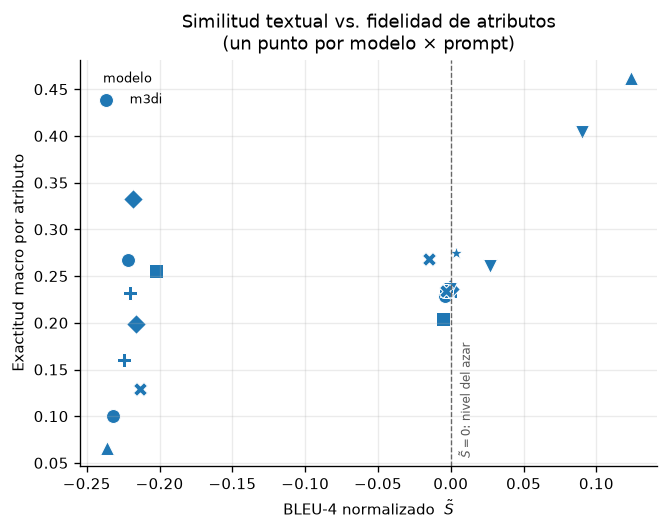

In [17]:
fig, ax = plt.subplots(figsize=(6.2, 4.4))
mk = ["o", "s", "^", "D", "v", "P", "X", "*"]
prompts = sorted(summary["prompt"].unique().to_list())
for mi, model in enumerate(sorted(summary["model"].unique().to_list())):
    s = summary.filter(pl.col("model") == model)
    for r in s.iter_rows(named=True):
        ax.scatter(
            r["bleu4_norm"],
            r["acc_macro"],
            marker=mk[prompts.index(r["prompt"]) % len(mk)],
            s=70,
            color=f"C{mi}",
            edgecolor="white",
            linewidth=0.6,
            label=model if r["prompt"] == s["prompt"][0] else None,
        )
ax.axvline(0, color="0.4", lw=0.8, ls="--")
ax.text(0.005, 0.02, "$\\tilde S=0$: nivel del azar", transform=ax.get_xaxis_transform(),
        fontsize=7, color="0.35", rotation=90, va="bottom")
ax.set_xlabel("BLEU-4 normalizado  $\\tilde S$")
ax.set_ylabel("Exactitud macro por atributo")
ax.set_title("Similitud textual vs. fidelidad de atributos\n(un punto por modelo × prompt)")
ax.legend(frameon=False, fontsize=8, title="modelo", title_fontsize=8)
fig.savefig(FIG_DIR / "plano_bleu_vs_atributos.png")
plt.show()

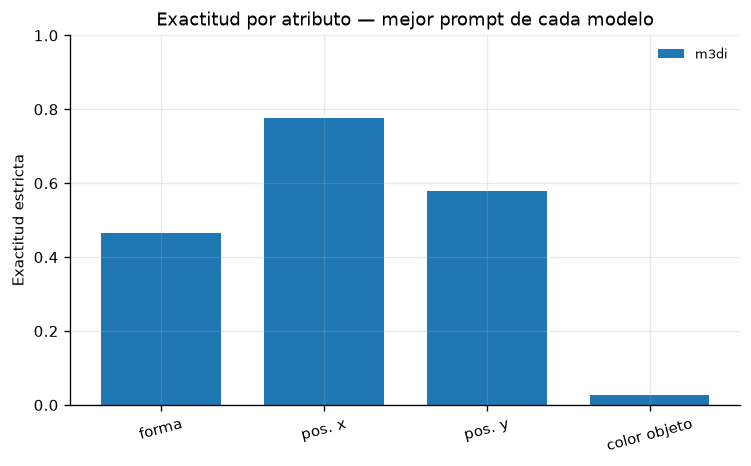

In [18]:
best_ids = best_run["exp_id"].to_list()
sub = attr_agg.filter(pl.col("exp_id").is_in(best_ids))
attrs_order = [a.label for a in ATTRS if a.label in sub["attribute"].unique().to_list()]
models_order = sorted({parse_exp_id(e)[0] for e in best_ids})

fig, ax = plt.subplots(figsize=(7.2, 4.0))
w = 0.8 / max(len(models_order), 1)
x = np.arange(len(attrs_order))
for mi, model in enumerate(models_order):
    eid = exp_of[model]
    vals = [
        float(sub.filter((pl.col("exp_id") == eid) & (pl.col("attribute") == a))["acc_estricta"][0])
        if sub.filter((pl.col("exp_id") == eid) & (pl.col("attribute") == a)).height
        else np.nan
        for a in attrs_order
    ]
    ax.bar(x + mi * w - 0.4 + w / 2, vals, width=w * 0.92, label=model, color=f"C{mi}")
ax.set_xticks(x, attrs_order, rotation=15)
ax.set_ylabel("Exactitud estricta")
ax.set_ylim(0, 1)
ax.set_title("Exactitud por atributo — mejor prompt de cada modelo")
ax.legend(frameon=False, fontsize=8, ncols=len(models_order))
fig.savefig(FIG_DIR / "exactitud_por_atributo.png")
plt.show()

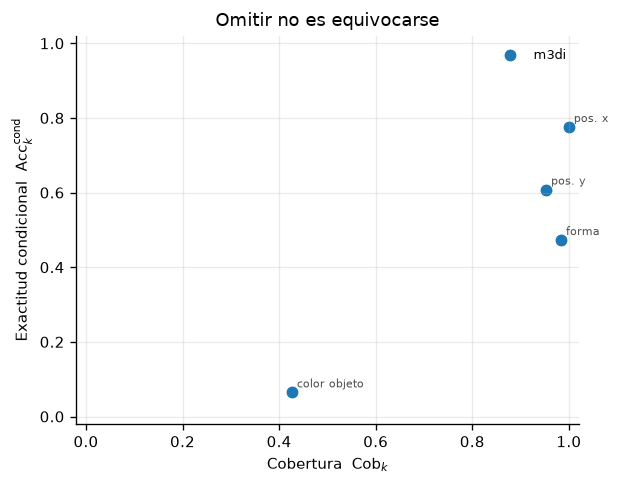

In [19]:
fig, ax = plt.subplots(figsize=(5.4, 4.2))
for mi, model in enumerate(models_order):
    s = attr_agg.filter(pl.col("exp_id") == exp_of[model])
    ax.scatter(s["cobertura"], s["acc_condicional"], s=60, color=f"C{mi}", label=model,
               edgecolor="white", linewidth=0.6)
    for r in s.iter_rows(named=True):
        ax.annotate(r["attribute"], (r["cobertura"], r["acc_condicional"]),
                    fontsize=6.5, xytext=(3, 3), textcoords="offset points", color="0.3")
ax.set_xlabel("Cobertura  $\\mathrm{Cob}_k$")
ax.set_ylabel("Exactitud condicional  $\\mathrm{Acc}_k^{\\mathrm{cond}}$")
ax.set_title("Omitir no es equivocarse")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.legend(frameon=False, fontsize=8)
fig.savefig(FIG_DIR / "cobertura_vs_condicional.png")
plt.show()

Atributo peor resuelto: color objeto


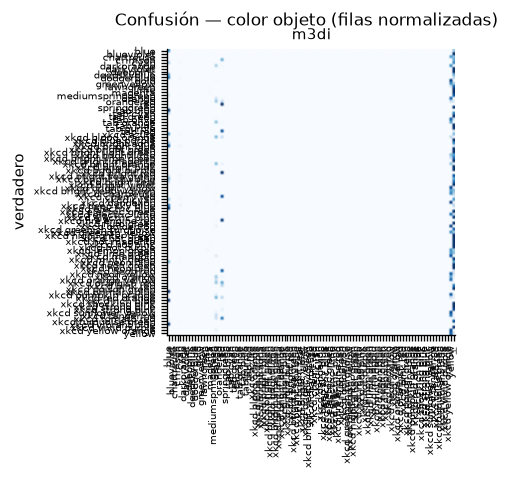

In [20]:
worst = (
    attr_agg.filter(pl.col("exp_id").is_in(best_ids))
    .group_by("attribute")
    .agg(pl.col("acc_estricta").mean())
    .sort("acc_estricta")
)
worst_attr = worst["attribute"][0]
print(f"Atributo peor resuelto: {worst_attr}")

fig, axes = plt.subplots(1, len(models_order), figsize=(3.1 * len(models_order), 3.1), squeeze=False)
for mi, model in enumerate(models_order):
    g = attr_long.filter((pl.col("exp_id") == exp_of[model]) & (pl.col("attribute") == worst_attr))
    labels = sorted({*g["y_true"].to_list()})
    cols = labels + ["⊥"]
    M = np.zeros((len(labels), len(cols)))
    for r in g.iter_rows(named=True):
        M[labels.index(r["y_true"]), cols.index(r["y_pred"] or "⊥")] += 1
    M = M / np.maximum(M.sum(axis=1, keepdims=True), 1)
    a = axes[0, mi]
    a.imshow(M, vmin=0, vmax=1, cmap="Blues")
    a.set_xticks(range(len(cols)), cols, rotation=90, fontsize=6)
    a.set_yticks(range(len(labels)), labels, fontsize=6)
    a.set_title(model, fontsize=9)
    a.grid(False)
    if mi == 0:
        a.set_ylabel("verdadero")
fig.suptitle(f"Confusión — {worst_attr} (filas normalizadas)", fontsize=10)
fig.savefig(FIG_DIR / f"confusion_{worst_attr.replace(' ', '_').replace('.', '')}.png")
plt.show()

In [21]:
print("Tablas:")
for p in sorted(TAB_DIR.glob("*")):
    print("  ", p.relative_to(ROOT))
print("Figuras:")
for p in sorted(FIG_DIR.glob("*.png")):
    print("  ", p.relative_to(ROOT))

print("\nPara el informe, reportar explícitamente:")
print(f"  · Línea base por permutación S_0: BLEU={S0['bleu4']:.4f}, "
      f"ROUGE-L={S0['rouge_l']:.4f}, CIDEr-D={S0['cider_d']:.4f}")
print("  · Exactitud del extractor sobre referencias (tabla de la sección 5.1)")
print("  · Regla de normalización de texto (sección 3) y criterio de selección de prompt")
print("  · CIDEr-D es poco discriminativo con captions plantillados: su IDF se degenera")

Tablas:
   reports/tables/eval/acc_conjunto_cerrado.csv
   reports/tables/eval/attribute_long.parquet
   reports/tables/eval/attribute_metrics.csv
   reports/tables/eval/discordancia.csv
   reports/tables/eval/summary_by_run.csv
Figuras:
   reports/figures/eval/cobertura_vs_condicional.png
   reports/figures/eval/confusion_color_objeto.png
   reports/figures/eval/exactitud_por_atributo.png
   reports/figures/eval/plano_bleu_vs_atributos.png

Para el informe, reportar explícitamente:
  · Línea base por permutación S_0: BLEU=0.2058, ROUGE-L=0.4554, CIDEr-D=0.5722
  · Exactitud del extractor sobre referencias (tabla de la sección 5.1)
  · Regla de normalización de texto (sección 3) y criterio de selección de prompt
  · CIDEr-D es poco discriminativo con captions plantillados: su IDF se degenera
